# Diffusion Summary-Dimension Comparison

Combine the saved NPE diagnostics for `S=D`, `S=2D`, and `S=4D`.

This notebook only reads saved diagnostic CSV files. It does not retrain networks, recompute NPE log marginal likelihoods, or refit typical-set references.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.results.summary_diagnostic import (
    MODELS,
    MODEL_TITLES,
    logml_diagnostic_frame,
    pmp_diagnostic_frame,
)

DIFFUSION_DIR = PROJECT_ROOT / "benchmark" / "examples" / "diffusion"
RESULT_DIR = DIFFUSION_DIR / "results"
FIGURE_DIR = RESULT_DIR / "plots" / "summary_dimension_comparison"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
summary_specs = [
    ("S=D", "S1D"),
    ("S=2D", "S2D"),
    ("S=4D", "S4D"),
]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError("None of these files exists: " + ", ".join(str(path) for path in paths))


def diagnostic_path(tag):
    return first_existing(
        [
            RESULT_DIR / f"npe_{tag}_empirical_diagnostic.csv",
        ]
    )


def read_diagnostic(label, tag):
    path = diagnostic_path(tag)
    frame = pd.read_csv(path)
    frame["summary_label"] = label
    frame["summary_tag"] = tag
    frame["source_path"] = str(path)
    return frame


diagnostic_by_summary = {
    label: read_diagnostic(label, tag)
    for label, tag in summary_specs
}

diagnostic_all = pd.concat(diagnostic_by_summary.values(), ignore_index=True)

for label, frame in diagnostic_by_summary.items():
    print(f"{label}: {len(frame)} empirical datasets from {Path(frame['source_path'].iloc[0]).name}")


S=D: 17 empirical datasets from npe_S1D_empirical_diagnostic.csv
S=2D: 17 empirical datasets from npe_S2D_empirical_diagnostic.csv
S=4D: 17 empirical datasets from npe_S4D_empirical_diagnostic.csv


In [3]:
required_columns = (
    {"id", "globally_high_surprise", "at_least_one_not_high_surprise", "summary_ambiguity", "log1p_summary_ambiguity"}
    | {f"rho_{model}" for model in MODELS}
    | {f"regime_{model}" for model in MODELS}
    | {f"signed_logml_error_{model}" for model in MODELS}
    | {f"signed_pmp_error_{model}" for model in MODELS}
)

missing = {
    label: sorted(required_columns - set(frame.columns))
    for label, frame in diagnostic_by_summary.items()
}
missing = {label: cols for label, cols in missing.items() if cols}
if missing:
    raise KeyError(missing)

summary_overview = []
for label, frame in diagnostic_by_summary.items():
    regime_columns = [f"regime_{model}" for model in MODELS]
    logml_columns = [f"signed_logml_error_{model}" for model in MODELS]
    pmp_columns = [f"signed_pmp_error_{model}" for model in MODELS]
    any_high_surprise = frame[regime_columns].eq("high surprise").any(axis=1)
    max_abs_logml = frame[logml_columns].abs().max(axis=1)
    max_abs_pmp = frame[pmp_columns].abs().max(axis=1)
    summary_overview.append(
        {
            "summary": label,
            "n": len(frame),
            "n_any_high_surprise": int(any_high_surprise.sum()),
            "n_global_high_surprise": int(frame["globally_high_surprise"].sum()),
            "max_abs_logml_error": float(max_abs_logml.max()),
            "median_abs_logml_error": float(max_abs_logml.median()),
            "max_abs_pmp_error": float(max_abs_pmp.max()),
            "max_log1p_A": float(frame["log1p_summary_ambiguity"].max()),
        }
    )

pd.DataFrame(summary_overview)


,summary,n,n_any_high_surprise,n_global_high_surprise,max_abs_logml_error,median_abs_logml_error,max_abs_pmp_error,max_log1p_A
0,S=D,17,2,0,8.890486,1.811402,0.339997,0.000000
1,S=2D,17,9,0,6.329655,1.640873,0.227622,0.000000
2,S=4D,17,12,2,8.993371,1.594805,0.567613,3.957317


## Plot Helpers

In [4]:
REGIME_COLORS = {
    "low surprise": "#E69F00",
    "in_distribution": "#0072B2",
    "high surprise": "#CC79A7",
}
POINT_COLOR = "#303030"
STRIP_COLOR = "#D9D9D9"
STRIP_EDGE = "0.35"
MARKERS = {
    False: {"marker": "o", "size": 34, "label": "all high surprise"},
    True: {"marker": "D", "size": 48, "label": "at least one not high surprise"},
}
PLOT_FONT = {"strip": 17, "label": 17, "ylabel": 16, "tick": 13, "legend": 13}


def model_index(model):
    return model.removeprefix("m")


COLUMN_LABELS = {model: rf"Assumed $M_{{{model_index(model)}}}$" for model in MODELS}


def add_rho_regions(ax, rho_low, x_max):
    ax.axvspan(0.0, rho_low, color=REGIME_COLORS["low surprise"], alpha=0.08)
    ax.axvspan(rho_low, 1.0, color=REGIME_COLORS["in_distribution"], alpha=0.07)
    ax.axvspan(1.0, x_max, color=REGIME_COLORS["high surprise"], alpha=0.07)
    ax.axvline(rho_low, color=REGIME_COLORS["low surprise"], linestyle="--", linewidth=1.0)
    ax.axvline(1.0, color=REGIME_COLORS["high surprise"], linestyle="--", linewidth=1.0)


def scatter_by_surprise(ax, data, x, y):
    for flag, style in MARKERS.items():
        group = data[data["at_least_one_not_high_surprise"] == flag]
        if group.empty:
            continue
        ax.scatter(
            group[x],
            group[y],
            s=style["size"],
            marker=style["marker"],
            color=POINT_COLOR,
            alpha=0.78,
            edgecolors="black",
            linewidths=0.55,
        )


def signed_max_error_within_rho(data, rho_max=1.0):
    subset = data.loc[data["rho"].le(rho_max), ["rho", "signed_pmp_error"]].dropna()
    if subset.empty:
        return None
    return float(subset.loc[subset["signed_pmp_error"].abs().idxmax(), "signed_pmp_error"])


def add_rho_max_error_line(ax, data):
    y0 = signed_max_error_within_rho(data)
    if y0 is None:
        return
    ax.axhline(y0, color="#882255", linestyle="--", linewidth=1.1)
    va = "bottom" if y0 >= 0 else "top"
    ax.text(
        0.98,
        y0,
        f"{y0:.2g}",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va=va,
        fontsize=11,
        color="#882255",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.65, "pad": 1.0},
    )


def marker_handles():
    return [
        Line2D(
            [0],
            [0],
            marker=style["marker"],
            color="none",
            markerfacecolor="0.45",
            markeredgecolor="black",
            markersize=7,
            label=style["label"],
        )
        for style in MARKERS.values()
    ]


def style_axes(axes):
    for ax in np.ravel(axes):
        ax.grid(alpha=0.18)
        ax.tick_params(labelsize=PLOT_FONT["tick"])
        ax.xaxis.label.set_size(PLOT_FONT["label"])
        ax.yaxis.label.set_size(PLOT_FONT["label"])


def add_facet_strips(fig, axes, row_labels, column_labels):
    fig.canvas.draw()
    strip_pad = 0.006
    top_height = 0.046
    side_width = 0.052

    for ax, label in zip(axes[0], column_labels, strict=False):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x0, pos.y1 + strip_pad, pos.width, top_height])
        strip.set_facecolor(STRIP_COLOR)
        strip.text(0.5, 0.5, label, ha="center", va="center", fontsize=PLOT_FONT["strip"])
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(STRIP_EDGE)
            spine.set_linewidth(0.8)

    for ax, label in zip(axes[:, -1], row_labels, strict=False):
        pos = ax.get_position()
        strip = fig.add_axes([pos.x1 + strip_pad, pos.y0, side_width, pos.height])
        strip.set_facecolor(STRIP_COLOR)
        strip.text(0.5, 0.5, label, ha="center", va="center", rotation=-90, fontsize=PLOT_FONT["strip"])
        strip.set_xticks([])
        strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_color(STRIP_EDGE)
            spine.set_linewidth(0.8)


def make_facet_grid(row_labels, sharey=False, sharex=False, figsize=None):
    figsize = figsize or (5.2 * len(MODELS) + 1.2, 3.0 * len(row_labels) + 1.4)
    fig, axes = plt.subplots(
        len(row_labels),
        len(MODELS),
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
    )
    axes = np.atleast_2d(axes)
    fig.subplots_adjust(left=0.17, right=0.86, bottom=0.17, top=0.88, wspace=0.08, hspace=0.28)
    return fig, axes


def finish_facet_figure(fig, axes, row_labels, ylabel, legend=False):
    style_axes(axes)
    add_facet_strips(fig, axes, row_labels, [COLUMN_LABELS[m] for m in MODELS])
    fig.supylabel(ylabel, x=0.055, fontsize=PLOT_FONT["ylabel"])
    if legend:
        fig.legend(
            handles=marker_handles(),
            loc="lower center",
            bbox_to_anchor=(0.5, 0.035),
            ncol=2,
            frameon=False,
            fontsize=PLOT_FONT["legend"],
        )
    return fig, axes


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)


## Log Marginal Likelihood Error vs Rho

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_dimension_comparison/combined_logml_error_vs_rho.png


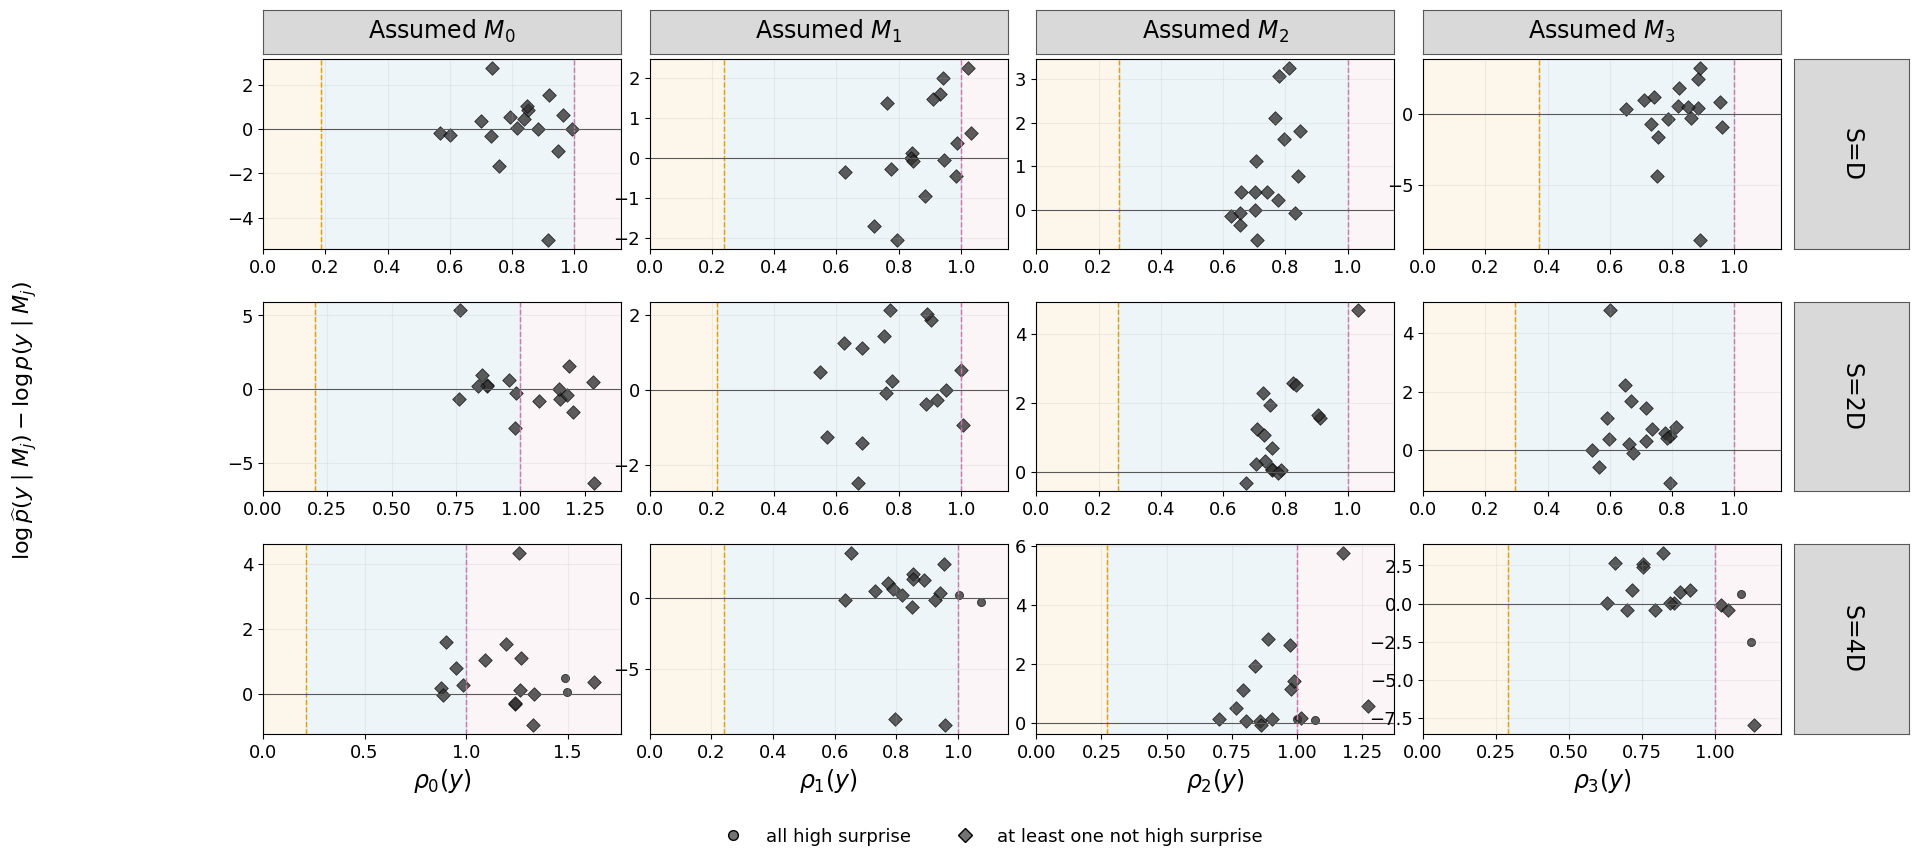

In [5]:
def plot_combined_logml_error_vs_rho(diagnostic_by_summary):
    row_labels = list(diagnostic_by_summary)
    fig, axes = make_facet_grid(row_labels, sharey=False, figsize=(5.2 * len(MODELS) + 1.2, 9.5))

    for r, label in enumerate(row_labels):
        data = logml_diagnostic_frame(diagnostic_by_summary[label])
        pmp_data = pmp_diagnostic_frame(diagnostic_by_summary[label])
        for c, model in enumerate(MODELS):
            ax = axes[r, c]
            sub = data[data["model"] == model].copy()
            marker_info = pmp_data[pmp_data["model"] == model][["id", "at_least_one_not_high_surprise"]]
            sub = sub.merge(marker_info, on="id", how="left")
            x_max = max(float(sub["rho"].max()) * 1.08, 1.15)
            add_rho_regions(ax, float(sub["rho_low"].iloc[0]), x_max)
            scatter_by_surprise(ax, sub, "rho", "signed_logml_error")
            ax.axhline(0.0, color="0.35", linewidth=0.8)
            ax.set_xlim(0.0, x_max)
            if r == len(row_labels) - 1:
                ax.set_xlabel(rf"$\rho_{{{model_index(model)}}}(y)$")
            else:
                ax.set_xlabel("")
            if c > 0:
                ax.set_ylabel("")

    finish_facet_figure(
        fig,
        axes,
        row_labels,
        r"$\log\widehat{ p}(y\mid M_j)-\log p(y\mid M_j)$",
        legend=True,
    )
    return fig, axes


fig_logml_rho, axes_logml_rho = plot_combined_logml_error_vs_rho(diagnostic_by_summary)
save_figure(fig_logml_rho, "combined_logml_error_vs_rho.png")


## PMP Error vs Rho

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_dimension_comparison/combined_pmp_error_vs_rho.png


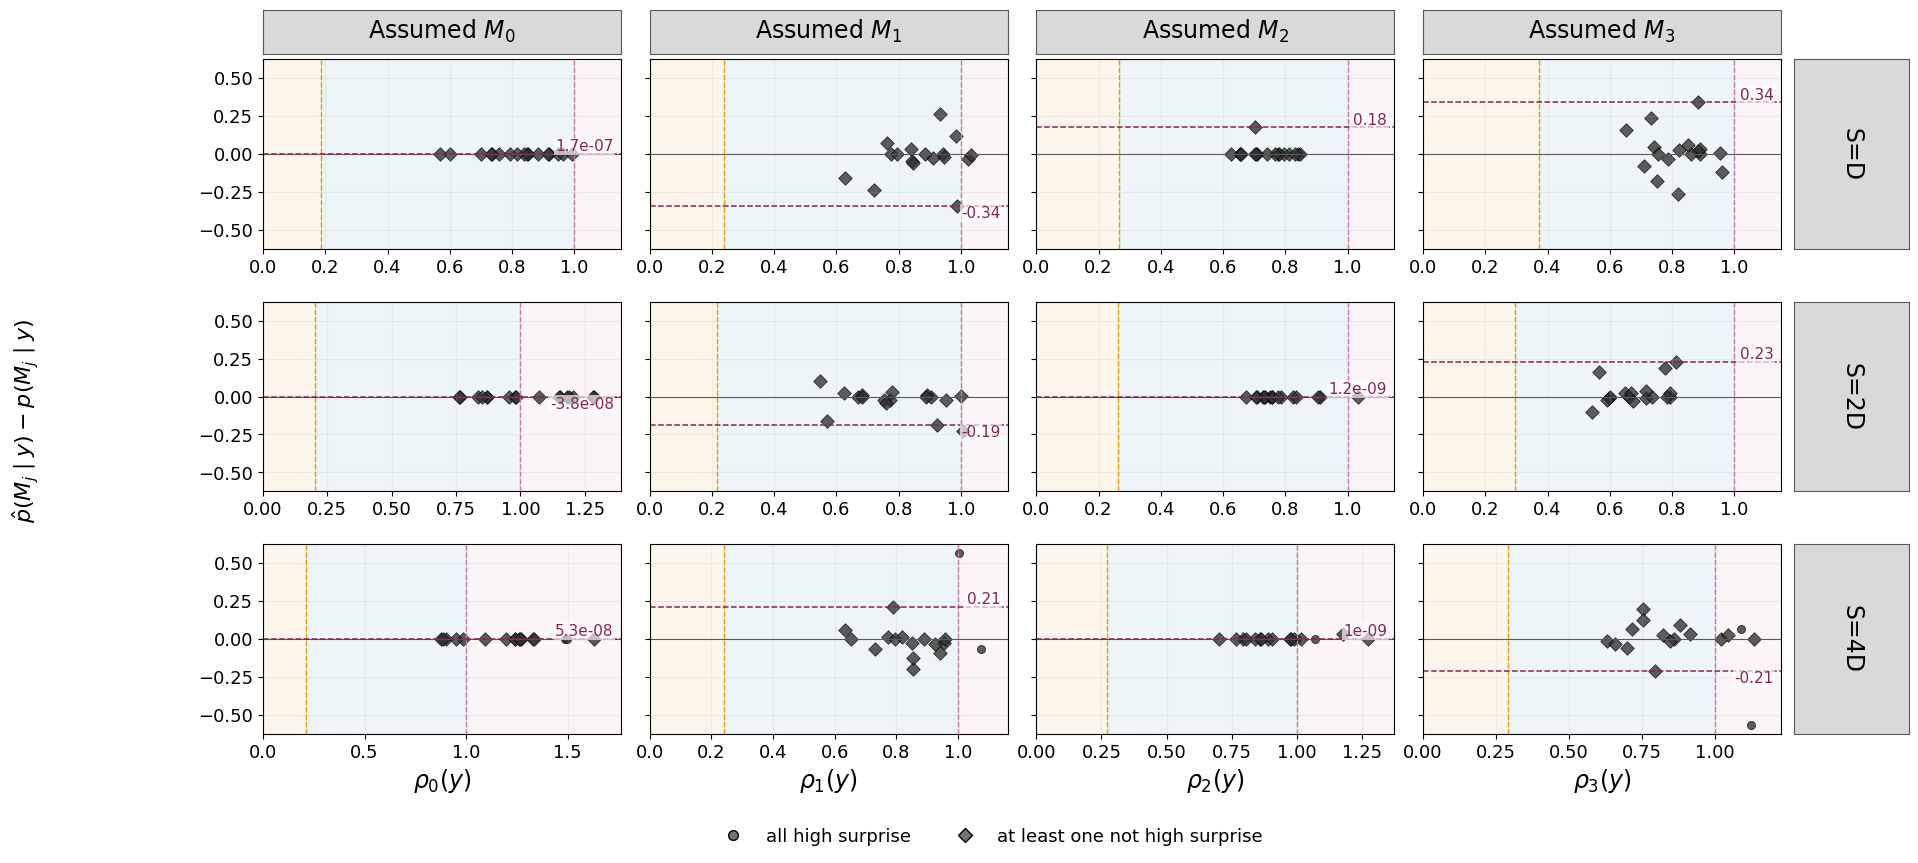

In [6]:
def plot_combined_pmp_error_vs_rho(diagnostic_by_summary):
    row_labels = list(diagnostic_by_summary)
    fig, axes = make_facet_grid(row_labels, sharey=True, figsize=(5.2 * len(MODELS) + 1.2, 9.5))

    for r, label in enumerate(row_labels):
        data = pmp_diagnostic_frame(diagnostic_by_summary[label])
        for c, model in enumerate(MODELS):
            ax = axes[r, c]
            sub = data[data["model"] == model]
            x_max = max(float(sub["rho"].max()) * 1.08, 1.15)
            add_rho_regions(ax, float(sub["rho_low"].iloc[0]), x_max)
            scatter_by_surprise(ax, sub, "rho", "signed_pmp_error")
            ax.axhline(0.0, color="0.35", linewidth=0.8)
            add_rho_max_error_line(ax, sub)
            ax.set_xlim(0.0, x_max)
            if r == len(row_labels) - 1:
                ax.set_xlabel(rf"$\rho_{{{model_index(model)}}}(y)$")
            else:
                ax.set_xlabel("")
            if c > 0:
                ax.set_ylabel("")

    finish_facet_figure(
        fig,
        axes,
        row_labels,
        r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$",
        legend=True,
    )
    return fig, axes


fig_pmp_rho, axes_pmp_rho = plot_combined_pmp_error_vs_rho(diagnostic_by_summary)
save_figure(fig_pmp_rho, "combined_pmp_error_vs_rho.png")


## PMP Error vs Summary Ambiguity

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/summary_dimension_comparison/combined_pmp_error_vs_log_ambiguity.png


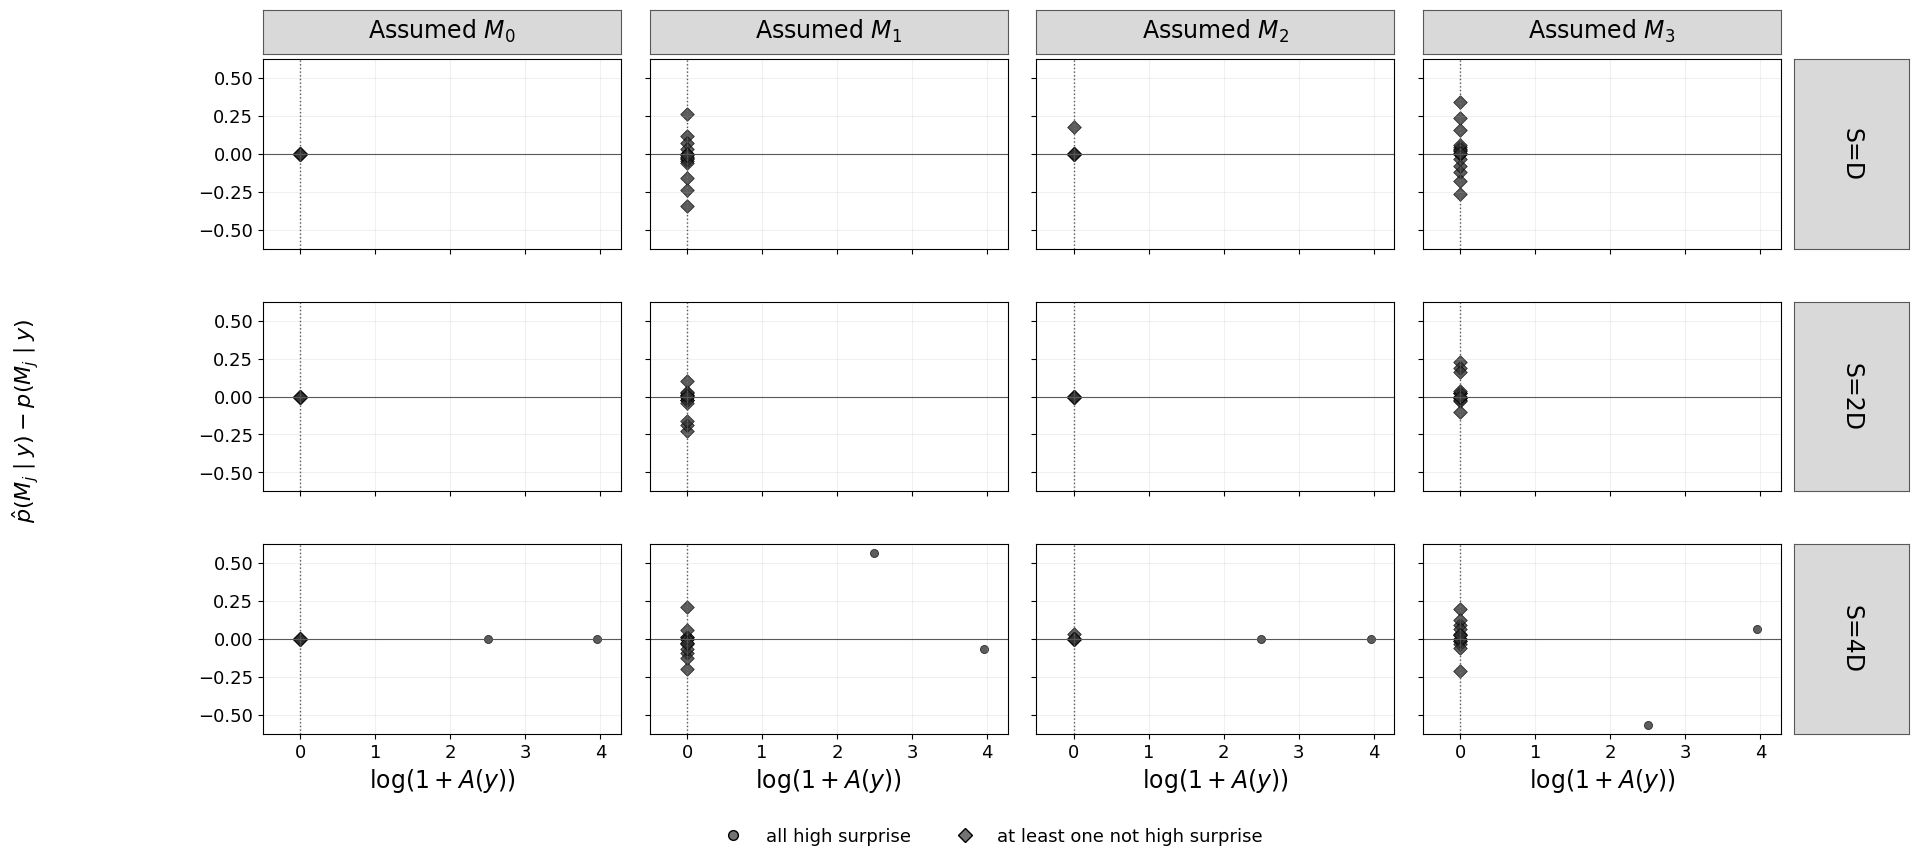

In [9]:
def plot_combined_pmp_error_vs_log_ambiguity(diagnostic_by_summary):
    row_labels = list(diagnostic_by_summary)
    all_data = [pmp_diagnostic_frame(frame) for frame in diagnostic_by_summary.values()]
    x_max = max(float(data["log1p_summary_ambiguity"].max()) for data in all_data)
    x_max = max(x_max * 1.08, 0.25)

    fig, axes = make_facet_grid(row_labels, sharey=True, sharex=True, figsize=(5.2 * len(MODELS) + 1.2, 9.5))

    for r, label in enumerate(row_labels):
        data = pmp_diagnostic_frame(diagnostic_by_summary[label])
        for c, model in enumerate(MODELS):
            ax = axes[r, c]
            sub = data[data["model"] == model]
            scatter_by_surprise(ax, sub, "log1p_summary_ambiguity", "signed_pmp_error")
            ax.axhline(0.0, color="0.35", linewidth=0.8)
            ax.axvline(0.0, color="0.35", linestyle=":", linewidth=1.0)
            ax.set_xlim(-0.5, x_max)
            if r == len(row_labels) - 1:
                ax.set_xlabel(r"$\log(1+A(y))$")
            else:
                ax.set_xlabel("")
            if c > 0:
                ax.set_ylabel("")

    finish_facet_figure(
        fig,
        axes,
        row_labels,
        r"$\hat{p}(M_j\mid y)-p(M_j\mid y)$",
        legend=True,
    )
    return fig, axes


fig_pmp_logA, axes_pmp_logA = plot_combined_pmp_error_vs_log_ambiguity(diagnostic_by_summary)
save_figure(fig_pmp_logA, "combined_pmp_error_vs_log_ambiguity.png")


## Largest Error Cases

In [8]:
largest_errors = diagnostic_all.copy()
logml_columns = [f"signed_logml_error_{model}" for model in MODELS]
rho_columns = [f"rho_{model}" for model in MODELS]
regime_columns = [f"regime_{model}" for model in MODELS]
pmp_error_columns = [f"signed_pmp_error_{model}" for model in MODELS]

largest_errors["max_abs_logml_error"] = largest_errors[logml_columns].abs().max(axis=1)
largest_errors["max_abs_pmp_error"] = largest_errors[pmp_error_columns].abs().max(axis=1)
largest_errors["max_rho"] = largest_errors[rho_columns].max(axis=1)

largest_errors[
    ["summary_label", "id"]
    + regime_columns
    + rho_columns
    + logml_columns
    + pmp_error_columns
    + ["max_abs_logml_error", "max_abs_pmp_error", "log1p_summary_ambiguity"]
].sort_values("max_abs_logml_error", ascending=False).head(12)


,summary_label,id,regime_m0,regime_m1,regime_m2,regime_m3,rho_m0,rho_m1,rho_m2,rho_m3,...,signed_logml_error_m1,signed_logml_error_m2,signed_logml_error_m3,signed_pmp_error_m0,signed_pmp_error_m1,signed_pmp_error_m2,signed_pmp_error_m3,max_abs_logml_error,max_abs_pmp_error,log1p_summary_ambiguity
47,S=4D,p13,high surprise,in_distribution,high surprise,high surprise,1.632496,0.957885,1.013790,1.018808,...,-8.993371,0.177238,-0.091226,7.398308e-28,-2.652174e-11,4.982087e-21,2.652190e-11,8.993371,2.652190e-11,0.0
2,S=D,p2,in_distribution,in_distribution,in_distribution,in_distribution,0.849941,0.942280,0.840489,0.889291,...,1.995508,0.773686,-8.890486,6.527526e-26,9.755554e-05,9.286040e-20,-9.755554e-05,8.890486,9.755554e-05,0.0
42,S=4D,p8,high surprise,in_distribution,in_distribution,in_distribution,1.240499,0.794667,0.859395,0.859089,...,-8.555186,0.046469,0.023672,-5.230200e-32,-7.589898e-05,2.376814e-30,7.589898e-05,8.555186,7.589898e-05,0.0
36,S=4D,p2,high surprise,in_distribution,high surprise,high surprise,1.327775,0.888317,1.271548,1.134078,...,1.280974,0.562143,-7.962470,4.072248e-27,1.887564e-05,2.970994e-20,-1.887564e-05,7.962470,1.887564e-05,0.0
30,S=2D,p13,high surprise,in_distribution,in_distribution,in_distribution,1.288287,0.886426,0.732556,0.736429,...,-0.384925,1.070820,0.744834,-1.313164e-27,-1.795472e-11,6.234962e-21,1.795475e-11,6.329655,1.795475e-11,0.0
40,S=4D,p6,high surprise,in_distribution,high surprise,in_distribution,1.262129,0.654660,1.175797,0.657998,...,3.191507,5.770272,2.659765,6.553150e-10,2.746674e-06,3.569830e-02,-3.570104e-02,5.770272,3.570104e-02,0.0
23,S=2D,p6,in_distribution,in_distribution,high surprise,in_distribution,0.763902,0.669991,1.032929,0.601299,...,-2.480909,4.686990,4.784018,1.161171e-10,-4.281788e-06,-1.597500e-04,1.640317e-04,5.338017,1.640317e-04,0.0
13,S=D,p13,in_distribution,in_distribution,in_distribution,in_distribution,0.916928,0.885426,0.709075,0.861667,...,-0.954458,-0.689894,-0.286031,-1.302579e-27,-1.293073e-11,-5.375391e-21,1.293077e-11,5.007760,1.293077e-11,0.0
6,S=D,p6,in_distribution,in_distribution,in_distribution,in_distribution,0.736869,0.775395,0.701152,0.750168,...,-0.279977,0.402056,-4.418061,1.685205e-07,2.171222e-04,1.751216e-01,-1.753388e-01,4.418061,1.753388e-01,0.0
38,S=4D,p4,high surprise,in_distribution,in_distribution,in_distribution,1.195349,0.953193,0.972155,0.819940,...,2.387195,2.652949,3.317888,-1.460653e-34,-2.922653e-02,1.168021e-35,2.922653e-02,3.317888,2.922653e-02,0.0
